In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
fake = pd.read_csv('../demos/Fake.csv')
true = pd.read_csv('../demos/True.csv')

# Add labels
fake['label'] = 0  # 0 = Fake
true['label'] = 1  # 1 = Real

# Combine
df = pd.concat([fake, true], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [5]:
import pandas as pd
import re
import nltk
import joblib
import os

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return ' '.join(words)

# Sample karo RAM bachane ke liye
df = df.sample(n=20000, random_state=42).reset_index(drop=True)

if 'text' in df.columns:
    source_column = 'text'
elif 'title' in df.columns:
    source_column = 'title'
else:
    raise Exception(f"No text column found. Available: {df.columns.tolist()}")

df['clean_text'] = df[source_column].apply(clean_text)

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 1))
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf = tfidf.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tf, y_train)
lr_pred = lr.predict(X_test_tf)

print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_tf, y_train)
rf_pred = rf.predict(X_test_tf)

print("\n" + "=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

# Save — absolute path use kar
save_path = 'C:/Users/yashk/OneDrive/Desktop/Fake News Detection System/VerifyNow/model'
os.makedirs(save_path, exist_ok=True)
joblib.dump(lr, f'{save_path}/fake_news_model.pkl')
joblib.dump(tfidf, f'{save_path}/tfidf_vectorizer.pkl')

print("\n✅ Model Saved Successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yashk\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


LOGISTIC REGRESSION
Accuracy: 0.98225
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2090
           1       0.98      0.99      0.98      1910

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000


RANDOM FOREST
Accuracy: 0.9955
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2090
           1       1.00      1.00      1.00      1910

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000


✅ Model Saved Successfully!


In [6]:
import os
print(os.getcwd())

c:\Users\yashk\OneDrive\Desktop\Fake News Detection System\VerifyNow\notebook


In [7]:
import joblib, os
os.makedirs('C:/Users/yashk/OneDrive/Desktop/Fake News Detection System/VerifyNow/model', exist_ok=True)
joblib.dump(lr, 'C:/Users/yashk/OneDrive/Desktop/Fake News Detection System/VerifyNow/model/fake_news_model.pkl')
joblib.dump(tfidf, 'C:/Users/yashk/OneDrive/Desktop/Fake News Detection System/VerifyNow/model/tfidf_vectorizer.pkl')
print("Saved!")

Saved!


In [8]:
plt.savefig('C:/Users/yashk/OneDrive/Desktop/Fake News Detection System/VerifyNow/model/confusion_matrix.png')

<Figure size 640x480 with 0 Axes>

Accuracy: 0.9822
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.98      2090
        Real       0.98      0.99      0.98      1910

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000



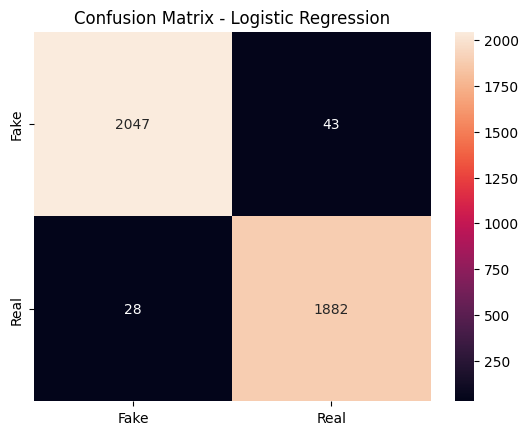

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")

# Detailed report
print(classification_report(y_test, lr_pred, target_names=['Fake', 'Real']))

# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=['Fake','Real'],
            yticklabels=['Fake','Real'])
plt.title('Confusion Matrix - Logistic Regression')
plt.savefig('../model/confusion_matrix.png')
plt.show()

In [10]:
import joblib, os
os.makedirs('C:/Users/yashk/OneDrive/Desktop/Fake News Detection System/VerifyNow/model', exist_ok=True)
joblib.dump(lr, 'C:/Users/yashk/OneDrive/Desktop/Fake News Detection System/VerifyNow/model/fake_news_model.pkl')
joblib.dump(tfidf, 'C:/Users/yashk/OneDrive/Desktop/Fake News Detection System/VerifyNow/model/tfidf_vectorizer.pkl')
print("Saved!")

Saved!
